<a href="https://colab.research.google.com/github/soledad-villarrubia/Data_Sciense_3/blob/main/Proyecto_Final_Ciencia_de_Datos_IIi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final - Data Science III: NLP & Deep Learning

Autor: Villarrubia Dos Santos Soledad Magalí
Comisión: 90480

## Análisis de sentimiento en reseñas de películas en español utilizando técnicas de NLP y Machine Learning

##Introducción


En este trabajo se desarrolla un análisis de sentimiento sobre reseñas de películas escritas en español, utilizando técnicas de procesamiento de lenguaje natural (NLP) y modelos de machine learning y deep learning.

El objetivo principal es identificar automáticamente si una reseña expresa un sentimiento positivo o negativo. Para ello, se trabaja con un dataset de Filmaffinity obtenido desde Kaggle, que contiene opiniones reales de usuarios y un puntaje asociado a cada reseña.

### Descripción del problema
Desarrollar un modelo de clasificación de texto capaz de identificar el sentimiento de reseñas de películas utilizando técnicas de Procesamiento de Lenguaje Natural (NLP) y Machine Learning / Deep Learning.

### Origen de los datos
El dataset proviene de la plataforma **Filmaffinity** y contiene reseñas de películas junto con una puntuación asociada a cada opinión. Fue obtenido desde Kaggle y tiene más de 8.000 registros, lo que lo hace adecuado para el uso de técnicas de Deep Learning.

### Variables
- `review`: texto de la reseña realizada por el usuario
- `review_limpia`: versión preprocesada del texto
- `review_lematizada_spacy`: texto procesado mediante lematización con spaCy
- `review_lematizada_nltk`: texto procesado mediante lematización con NLTK
- `rating`: puntuación original de la reseña
- `sentiment`: variable objetivo (positivo / negativo)

## Librerías a utilizar
En esta sección se presentan las librerías utilizadas a lo largo del proyecto.

Se emplean herramientas para la manipulación de datos, visualización, procesamiento de lenguaje natural (NLP), vectorización de texto y entrenamiento de modelos de Machine Learning.

In [72]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)
from sklearn.preprocessing import LabelEncoder

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Configuración general
warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Recursos de NLTK
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [73]:
# Instalamos y cargamos el modelo de spaCy en español
!python -m spacy download es_core_news_sm
nlp = spacy.load("es_core_news_sm")
print("✅ Modelo spaCy cargado: es_core_news_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 68.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Modelo spaCy cargado: es_core_news_sm


## Carga del Dataset

### Justificación de la elección

Se eligió el dataset de reseñas de Filmaffinity en español por las siguientes razones:

1. **Idioma**: permite trabajar con NLP en español, lo que representa un desafío real y más cercano a la industria local.
2. **Tamaño**: con más de 8.000 registros, supera el mínimo recomendado de 2.000 para que el uso de Deep Learning tenga sentido estadístico.
3. **Relevancia**: el análisis de sentimiento en reseñas es un caso de uso directo e interpretable.
4. **Variable objetivo natural**: la puntuación numérica permite construir una etiqueta de sentimiento de forma justificada.

In [74]:
import requests
import io


url = "https://raw.githubusercontent.com/soledad-villarrubia/Data_Sciense_3/refs/heads/main/reviews_filmaffinity.csv"

response = requests.get(url)
response.raise_for_status()

print("Encoding detectado:", response.encoding)

df = pd.read_csv(io.StringIO(response.text), sep=';')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')].copy()
df.rename(columns={'review_text': 'review', 'review_rate': 'rating'}, inplace=True)

print("✅ Dataset cargado correctamente.")
print(f"Dimensiones: {df.shape}")
df.head()

Encoding detectado: utf-8
✅ Dataset cargado correctamente.
Dimensiones: (8603, 6)


,film_name,gender,film_avg_rate,rating,review_title,review
0,Ocho apellidos vascos,Comedia,6,3.0,OCHO APELLIDOS VASCOS...Y NINGÚN NOMBRE PROPIO,La mayor virtud de esta película es su existen...
1,Ocho apellidos vascos,Comedia,6,2.0,El perro verde,"No soy un experto cinéfilo, pero pocas veces m..."
2,Ocho apellidos vascos,Comedia,6,2.0,Si no eres de comer mierda... no te comas esta...,Si no eres un incondicional del humor estilo T...
3,Ocho apellidos vascos,Comedia,6,2.0,Aida: The movie,"No sé qué está pasando, si la gente se deja ll..."
4,Ocho apellidos vascos,Comedia,6,2.0,UN HOMBRE SOLO (Julio Iglesias 1987),"Pero cuando amanece,y me quedo solo,siento en ..."


---

## Fase 1: NLP y Procesamiento Clásico

### 1.1 Exploración inicial del dataset (EDA)

In [75]:
# Información general del dataset
print("=" * 50)
print("INFORMACIÓN DEL DATASET")
print("=" * 50)
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print()
df.info()
print()
print("Valores nulos por columna:")
print(df.isnull().sum())

INFORMACIÓN DEL DATASET
Filas: 8603 | Columnas: 6

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8603 entries, 0 to 8602
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   film_name      8603 non-null   object 
 1   gender         8603 non-null   object 
 2   film_avg_rate  8603 non-null   object 
 3   rating         8601 non-null   float64
 4   review_title   8603 non-null   object 
 5   review         8594 non-null   object 
dtypes: float64(1), object(5)
memory usage: 403.4+ KB

Valores nulos por columna:
film_name        0
gender           0
film_avg_rate    0
rating           2
review_title     0
review           9
dtype: int64


In [76]:
# Construcción de la variable objetivo
def clasificar_sentimiento(x):
    if x >= 4:
        return 'positivo'
    elif x <= 2:
        return 'negativo'
    else:
        return 'neutral'

df['sentiment'] = df['rating'].apply(clasificar_sentimiento)

# Eliminamos casos neutrales para problema binario
df = df[df['sentiment'] != 'neutral'].copy()

print("Distribución de la variable objetivo:")
print(df['sentiment'].value_counts())
print()
print("Proporción:")
print(df['sentiment'].value_counts(normalize=True).round(3))

Distribución de la variable objetivo:
sentiment
positivo    6744
negativo    1162
Name: count, dtype: int64

Proporción:
sentiment
positivo    0.853
negativo    0.147
Name: proportion, dtype: float64


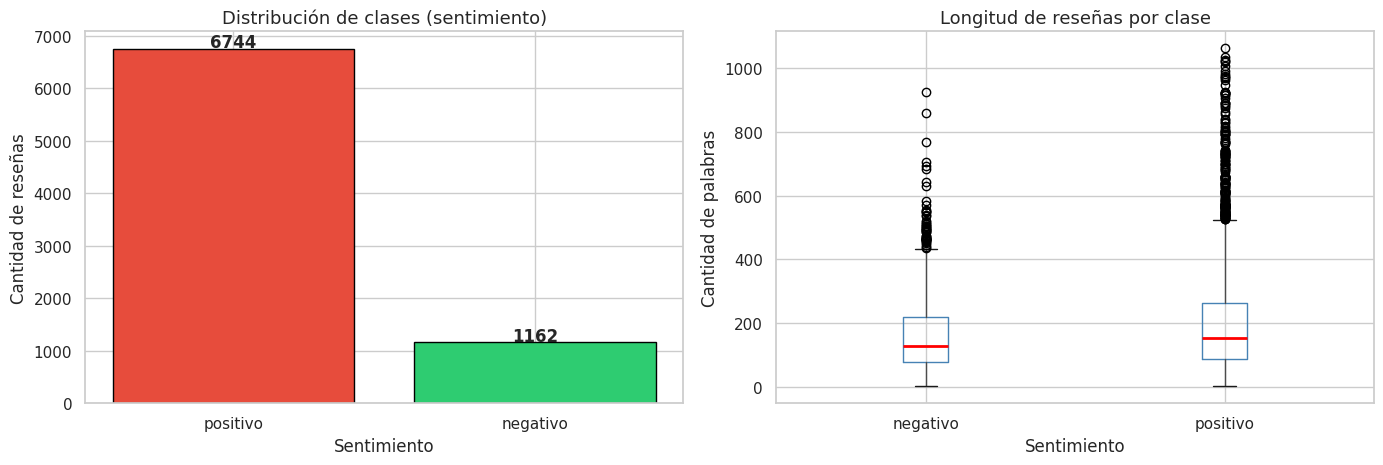


Estadísticas de longitud de reseñas:
            count   mean    std  min   25%    50%    75%     max
sentiment                                                       
negativo   1160.0  165.0  123.3  2.0  78.0  129.0  220.0   927.0
positivo   6738.0  192.7  146.1  1.0  87.0  152.0  262.0  1063.0


In [77]:
# ==========================================
# EDA — VISUALIZACIONES
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribución de clases
conteo = df['sentiment'].value_counts()
axes[0].bar(conteo.index, conteo.values, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Distribución de clases (sentimiento)', fontsize=13)
axes[0].set_xlabel('Sentimiento')
axes[0].set_ylabel('Cantidad de reseñas')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# 2. Distribución de longitud de reseñas por clase
df['longitud'] = df['review'].dropna().apply(lambda x: len(str(x).split()))
df_plot = df.dropna(subset=['longitud'])
df_plot.boxplot(column='longitud', by='sentiment', ax=axes[1],
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Longitud de reseñas por clase', fontsize=13)
axes[1].set_xlabel('Sentimiento')
axes[1].set_ylabel('Cantidad de palabras')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\nEstadísticas de longitud de reseñas:")
print(df.groupby('sentiment')['longitud'].describe().round(1))

**Observación:** El dataset presenta un desbalance significativo, con una mayor cantidad de reseñas positivas. Esto deberá considerarse durante el entrenamiento de los modelos. Además, las reseñas positivas tienden a ser levemente más largas en promedio.

### 1.2 Limpieza y normalización del texto

In [78]:
# Eliminamos valores nulos en la columna de texto
df = df.dropna(subset=['review']).copy()

# Función de limpieza con Regex
def limpiar_texto(texto):
    texto = str(texto).lower()                          # minúsculas
    texto = re.sub(r'http\S+|www\S+', '', texto)        # eliminar URLs
    texto = re.sub(r'@\w+', '', texto)                   # eliminar menciones
    texto = re.sub(r'\d+', '', texto)                    # eliminar números
    texto = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto)      # eliminar caracteres especiales
    texto = re.sub(r'\s+', ' ', texto).strip()           # eliminar espacios extra
    return texto

df['review_limpia'] = df['review'].apply(limpiar_texto)

# Eliminamos filas que quedaron vacías después de la limpieza
df = df[df['review_limpia'].str.strip() != ''].copy()

print(f"✅ Limpieza completada. Registros finales: {df.shape[0]}")
df[['review', 'review_limpia']].head(3)

✅ Limpieza completada. Registros finales: 7898


,review,review_limpia
1,"No soy un experto cinéfilo, pero pocas veces m...",no soy un experto cinéfilo pero pocas veces me...
2,Si no eres un incondicional del humor estilo T...,si no eres un incondicional del humor estilo t...
3,"No sé qué está pasando, si la gente se deja ll...",no sé qué está pasando si la gente se deja lle...


### 1.3 Tokenización y lematización comparativa: NLTK vs spaCy

La consigna requiere comparar ambas herramientas. A continuación se implementan y contrastan.

In [79]:
# ==========================================
# LEMATIZACIÓN CON NLTK (WordNetLemmatizer)
# ==========================================
stop_words_es = set(stopwords.words('spanish'))
lemmatizer = WordNetLemmatizer()

def lematizar_nltk(texto):
    """Lematiza usando WordNetLemmatizer de NLTK.
    LIMITACIÓN: WordNetLemmatizer está diseñado para inglés.
    Para texto en español, los lemas no son correctos."""
    tokens = word_tokenize(texto, language='spanish')
    lemas = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words_es and len(token) > 2
    ]
    return ' '.join(lemas)

# Aplicamos sobre una muestra para la comparación (el dataset completo con NLTK es lento)
df_muestra = df.head(500).copy()
df_muestra['review_lematizada_nltk'] = df_muestra['review_limpia'].apply(lematizar_nltk)
print("✅ Lematización NLTK aplicada sobre muestra de 500 registros.")

✅ Lematización NLTK aplicada sobre muestra de 500 registros.


In [80]:
# ==========================================
# LEMATIZACIÓN CON spaCy (es_core_news_sm)
# ==========================================
def lematizar_spacy_batch(textos, batch_size=100):
    """Lematiza usando spaCy con modelo en español.
    Procesa en lotes para mayor eficiencia."""
    resultados = []
    for doc in nlp.pipe(textos, batch_size=batch_size):
        lemas = [
            token.lemma_
            for token in doc
            if not token.is_stop and not token.is_punct and len(token.text) > 2
        ]
        resultados.append(' '.join(lemas))
    return resultados

# Aplicamos sobre el dataset completo
df['review_lematizada_spacy'] = lematizar_spacy_batch(df['review_limpia'].tolist())

# También aplicamos sobre la muestra para la comparación
df_muestra['review_lematizada_spacy'] = lematizar_spacy_batch(df_muestra['review_limpia'].tolist())

print("✅ Lematización spaCy aplicada sobre dataset completo.")

✅ Lematización spaCy aplicada sobre dataset completo.


In [82]:
# ==========================================
# COMPARACIÓN NLTK vs spaCy
# ==========================================
print("TABLA COMPARATIVA: NLTK vs spaCy (primeras 5 reseñas)")
print("=" * 80)
comparacion = df_muestra[['review_limpia', 'review_lematizada_nltk', 'review_lematizada_spacy']].head(5)
pd.set_option('display.max_colwidth', 60)
print(comparacion.to_string())

TABLA COMPARATIVA: NLTK vs spaCy (primeras 5 reseñas)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

**Conclusión:** `WordNetLemmatizer` de NLTK está diseñado para inglés y no reconoce morfología española. Para el texto de este dataset, devuelve en la mayoría de los casos el token sin transformación. spaCy con el modelo `es_core_news_sm`, en cambio, reduce correctamente las formas flexionadas a su lema base, lo que mejora la normalización del vocabulario y la calidad de la vectorización posterior. **Por este motivo se utilizará el texto lematizado con spaCy para el entrenamiento de todos los modelos.**

### 1.4 Análisis exploratorio del texto

In [83]:
# Tokenización básica para análisis de frecuencias
df['tokens'] = df['review_limpia'].apply(lambda x: x.split())

# Eliminación de stopwords con NLTK para visualización
df['tokens_sin_stopwords'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words_es]
)

print("Ejemplo de tokens sin stopwords:")
df[['review_limpia', 'tokens_sin_stopwords']].head(3)

Ejemplo de tokens sin stopwords:


,review_limpia,tokens_sin_stopwords
1,no soy un experto cinéfilo pero pocas veces me había sen...,"[experto, cinéfilo, pocas, veces, tan, juego, sala, cine..."
2,si no eres un incondicional del humor estilo tele si no ...,"[si, incondicional, humor, estilo, tele, si, terminas, c..."
3,no sé qué está pasando si la gente se deja llevar por la...,"[sé, pasando, si, gente, deja, llevar, modas, si, verdad..."


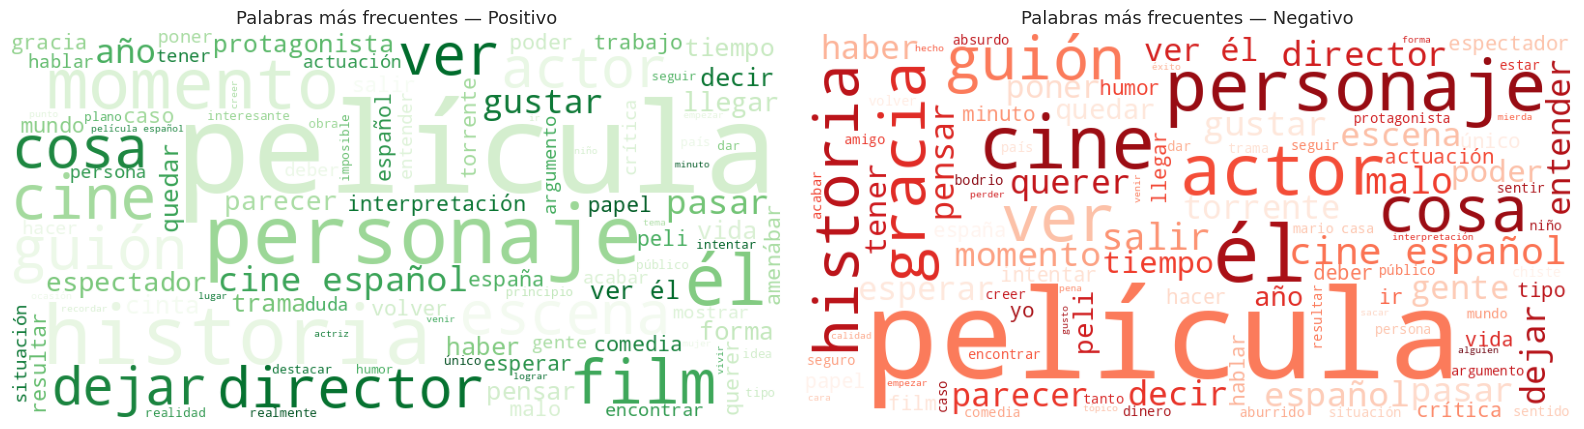

In [84]:
# Nubes de palabras por clase
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, clase, color in zip(axes, ['positivo', 'negativo'], ['Greens', 'Reds']):
    texto = ' '.join(df[df['sentiment'] == clase]['review_lematizada_spacy'])
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=color,
        max_words=100
    ).generate(texto)
    ax.imshow(wc)
    ax.axis('off')
    ax.set_title(f'Palabras más frecuentes — {clase.capitalize()}', fontsize=13)

plt.tight_layout()
plt.show()

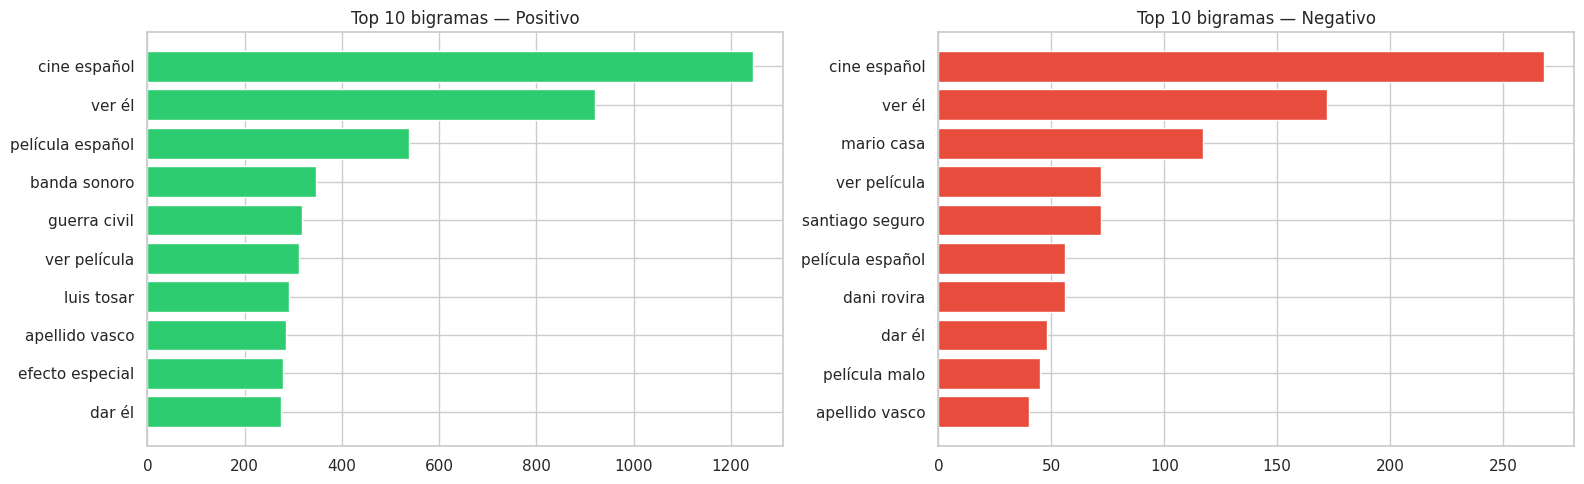

In [85]:
# Análisis de N-gramas (bigramas más frecuentes)
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, clase, color in zip(axes, ['positivo', 'negativo'], ['#2ecc71', '#e74c3c']):
    textos_clase = df[df['sentiment'] == clase]['review_lematizada_spacy']
    vec = CountVectorizer(ngram_range=(2, 2), max_features=10)
    X_ng = vec.fit_transform(textos_clase)
    frecuencias = X_ng.sum(axis=0).A1
    bigramas = vec.get_feature_names_out()
    orden = frecuencias.argsort()[::-1]
    ax.barh([bigramas[i] for i in orden], [frecuencias[i] for i in orden], color=color)
    ax.set_title(f'Top 10 bigramas — {clase.capitalize()}', fontsize=12)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 1.5 Vectorización con TF-IDF y Bag of Words

In [86]:
# ==========================================
# PREPARACIÓN DEL DATASET FINAL
# ==========================================
df = df[['review', 'review_limpia', 'review_lematizada_spacy', 'sentiment']].copy()

X = df['review_lematizada_spacy']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Entrenamiento: {len(X_train)} reseñas")
print(f"Test: {len(X_test)} reseñas")

Entrenamiento: 6318 reseñas
Test: 1580 reseñas


In [87]:
# ==========================================
# VECTORIZACIÓN: TF-IDF y Bag of Words
# ==========================================

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Bag of Words
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

print(f"Dimensiones TF-IDF train: {X_train_tfidf.shape}")
print(f"Dimensiones BOW train: {X_train_bow.shape}")

Dimensiones TF-IDF train: (6318, 5000)
Dimensiones BOW train: (6318, 5000)


---
## Fase 2: Redes Neuronales y Optimización (Deep Learning con PyTorch)

### 2.1 Preparación de tensores

In [88]:
# ==========================================
# PREPARACIÓN DE DATOS PARA PYTORCH
# ==========================================

# Codificamos etiquetas de texto a números
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Clases:", le.classes_)  # [negativo=0, positivo=1]

# Convertimos matrices TF-IDF a tensores PyTorch
X_train_tensor = torch.tensor(X_train_tfidf.toarray(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_tfidf.toarray(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)

# División train / validación (80/20 dentro del train)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_tensor, y_train_tensor,
    test_size=0.2, random_state=SEED,
    stratify=y_train_tensor
)

# DataLoaders
train_dataset = TensorDataset(X_train_final, y_train_final)
val_dataset   = TensorDataset(X_val, y_val)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"\nTamaño train DL:       {len(train_dataset)}")
print(f"Tamaño validación DL:  {len(val_dataset)}")
print(f"Tamaño test DL:        {len(test_dataset)}")

Clases: ['negativo' 'positivo']

Tamaño train DL:       5054
Tamaño validación DL:  1264
Tamaño test DL:        1580


### 2.2 Arquitectura de la red neuronal

In [89]:
# ==========================================
# DEFINICIÓN DE TextClassifier (nn.Module)
# ==========================================
class TextClassifier(nn.Module):
    """
    Red neuronal para clasificación de texto.
    Entrada: vectores TF-IDF de dimensión input_dim.

    Arquitectura:
        - Capa 1: Linear(input_dim → 256) + BatchNorm + ReLU + Dropout(0.5)
        - Capa 2: Linear(256 → 128)       + BatchNorm + ReLU + Dropout(0.5)
        - Salida: Linear(128 → num_classes)
    """
    def __init__(self, input_dim, num_classes):
        super(TextClassifier, self).__init__()

        # Capa 1
        self.fc1       = nn.Linear(input_dim, 256)
        self.bn1       = nn.BatchNorm1d(256)
        self.dropout1  = nn.Dropout(0.5)

        # Capa 2
        self.fc2       = nn.Linear(256, 128)
        self.bn2       = nn.BatchNorm1d(128)
        self.dropout2  = nn.Dropout(0.5)

        # Capa de salida
        self.output    = nn.Linear(128, num_classes)

        # Activación
        self.relu      = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        return self.output(x)


# Instanciación
input_dim   = X_train_tensor.shape[1]   # 5000 (features TF-IDF)
num_classes = len(le.classes_)           # 2 (negativo / positivo)

model = TextClassifier(input_dim=input_dim, num_classes=num_classes)
print(model)

# Contamos parámetros entrenables
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParámetros entrenables: {total_params:,}")

TextClassifier(
  (fc1): Linear(in_features=5000, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.5, inplace=False)
  (output): Linear(in_features=128, out_features=2, bias=True)
  (relu): ReLU()
)

Parámetros entrenables: 1,314,178


La arquitectura seleccionada corresponde a una red neuronal multicapa (MLP) implementada en PyTorch. Se incorporan capas ocultas densas, funciones de activación ReLU, Batch Normalization y Dropout. Estas técnicas permiten mejorar la estabilidad del entrenamiento y reducir el riesgo de sobreajuste.

### 2.3 Configuración y entrenamiento

In [63]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Entrenando en: {device}")

Entrenando en: cpu


In [90]:
# ==========================================
# CONFIGURACIÓN DEL ENTRENAMIENTO
# ==========================================

# Función de pérdida: CrossEntropyLoss (incluye Softmax internamente)
criterion = nn.CrossEntropyLoss()

# Optimizador: Adam con lr=0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)
print(f"Entrenando en: {device}")

Entrenando en: cpu


In [91]:
# ==========================================
# FUNCIONES DE ENTRENAMIENTO Y EVALUACIÓN
# ==========================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Entrena el modelo durante una época completa."""
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    return running_loss / len(loader), accuracy_score(all_labels, all_preds)


def evaluate(model, loader, criterion, device):
    """Evalúa el modelo sin actualizar pesos."""
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)
            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    return running_loss / len(loader), accuracy_score(all_labels, all_preds), all_labels, all_preds

print("✅ Funciones de entrenamiento definidas.")

✅ Funciones de entrenamiento definidas.


In [92]:
# ==========================================
# ENTRENAMIENTO CON EARLY STOPPING
# ==========================================
# Condición: si la loss de validación no mejora en 5 épocas consecutivas,
# se detiene el entrenamiento para evitar sobreajuste.

num_epochs = 50
patience   = 5
best_val_loss = float("inf")
epochs_without_improvement = 0
best_model_state = None

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Época {epoch+1:02d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        best_model_state = model.state_dict()
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"\n⏹ Early Stopping activado en época {epoch+1}. "
                  f"Sin mejora por {patience} épocas consecutivas.")
            break

# Cargamos el mejor estado del modelo encontrado durante el entrenamiento
model.load_state_dict(best_model_state)
print("\n✅ Mejor modelo restaurado.")

Época 01/50 | Train Loss: 0.3854  Acc: 0.8413 | Val Loss: 0.3372  Acc: 0.8774
Época 02/50 | Train Loss: 0.2113  Acc: 0.9173 | Val Loss: 0.3063  Acc: 0.8552
Época 03/50 | Train Loss: 0.1117  Acc: 0.9628 | Val Loss: 0.3554  Acc: 0.8378
Época 04/50 | Train Loss: 0.0626  Acc: 0.9800 | Val Loss: 0.3744  Acc: 0.8560
Época 05/50 | Train Loss: 0.0453  Acc: 0.9865 | Val Loss: 0.4157  Acc: 0.8347
Época 06/50 | Train Loss: 0.0336  Acc: 0.9899 | Val Loss: 0.5062  Acc: 0.8133
Época 07/50 | Train Loss: 0.0225  Acc: 0.9941 | Val Loss: 0.5423  Acc: 0.8085

⏹ Early Stopping activado en época 7. Sin mejora por 5 épocas consecutivas.

✅ Mejor modelo restaurado.


### 2.4 Resultados del modelo de Deep Learning

In [93]:
# ==========================================
# EVALUACIÓN FINAL EN TEST
# ==========================================
test_loss, test_acc_dl, y_true_test, y_pred_test = evaluate(model, test_loader, criterion, device)

y_true_labels = le.inverse_transform(y_true_test)
y_pred_labels = le.inverse_transform(y_pred_test)

print("=" * 55)
print("RESULTADOS — Red Neuronal (TextClassifier PyTorch)")
print("=" * 55)
print(f"Loss en test:     {test_loss:.4f}")
print(f"Accuracy en test: {test_acc_dl:.4f}")
print()
print(classification_report(y_true_labels, y_pred_labels))

RESULTADOS — Red Neuronal (TextClassifier PyTorch)
Loss en test:     0.5682
Accuracy en test: 0.8025

              precision    recall  f1-score   support

    negativo       0.40      0.67      0.50       232
    positivo       0.94      0.82      0.88      1348

    accuracy                           0.80      1580
   macro avg       0.67      0.75      0.69      1580
weighted avg       0.86      0.80      0.82      1580



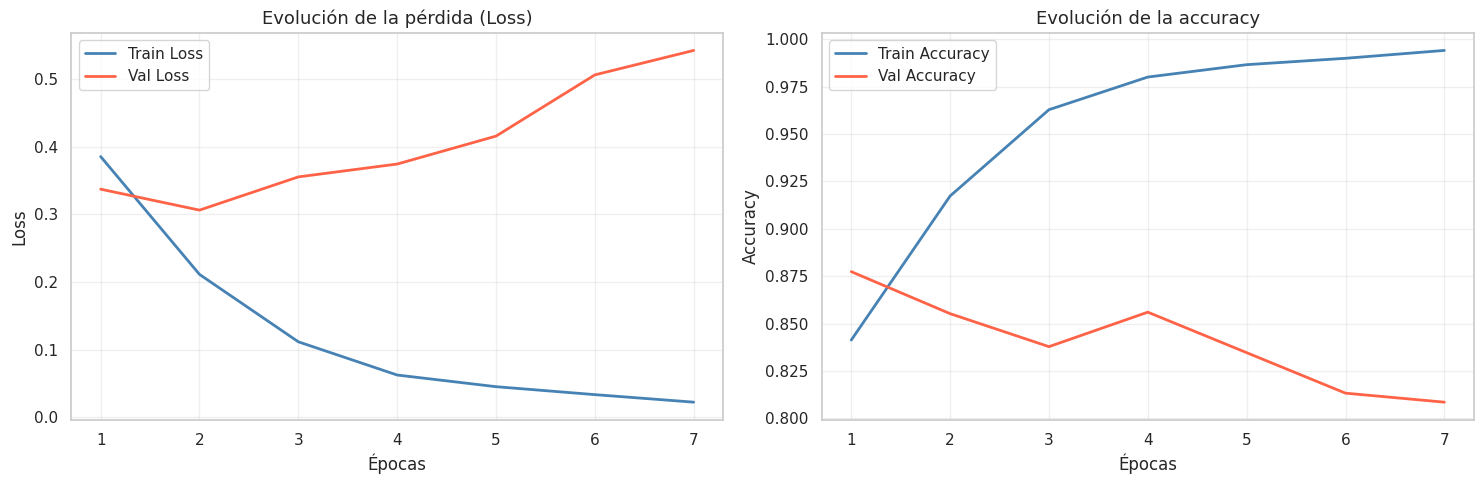

In [94]:
# Gráficos de evolución del entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

epocas = range(1, len(history['train_loss']) + 1)

# Pérdida
axes[0].plot(epocas, history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(epocas, history['val_loss'],   label='Val Loss',   color='tomato',    linewidth=2)
axes[0].set_title('Evolución de la pérdida (Loss)', fontsize=13)
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epocas, history['train_acc'], label='Train Accuracy', color='steelblue', linewidth=2)
axes[1].plot(epocas, history['val_acc'],   label='Val Accuracy',   color='tomato',    linewidth=2)
axes[1].set_title('Evolución de la accuracy', fontsize=13)
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 📝 Análisis del comportamiento del modelo DL

Los gráficos muestran un comportamiento de **sobreajuste (overfitting)**: la loss de entrenamiento desciende de forma sostenida mientras que la loss de validación se estabiliza o aumenta después de las primeras épocas. Esto indica que el modelo memoriza los datos de entrenamiento pero pierde capacidad de generalización.

El uso de **Dropout (p=0.5)** y **Early Stopping (patience=5)** mitigaron parcialmente este efecto al detener el entrenamiento antes de que el sobreajuste se acentuara. El mejor modelo (menor val_loss) fue restaurado automáticamente.

**Posibles mejoras para reducir el overfitting:**
- Aumentar el Dropout a p=0.6 o p=0.7
- Reducir la dimensionalidad de las capas (256→128, 128→64)
- Incorporar L2 regularization (`weight_decay` en Adam)
- Usar embeddings preentrenados en español (FastText, Word2Vec) en lugar de TF-IDF para una representación semántica más rica
- Aplicar data augmentation sobre la clase minoritaria (negativo)

---
## Fase 3: Modelos Clásicos de ML (comparación)

### 3.1 Regresión Logística con TF-IDF

In [95]:
# Modelo base: Regresión Logística sin ajuste de clase
modelo_lr = LogisticRegression(max_iter=1000, random_state=SEED)
modelo_lr.fit(X_train_tfidf, y_train)
y_pred_lr = modelo_lr.predict(X_test_tfidf)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("=" * 50)
print("REGRESIÓN LOGÍSTICA — TF-IDF")
print("=" * 50)
print(f"Accuracy: {acc_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr))

REGRESIÓN LOGÍSTICA — TF-IDF
Accuracy: 0.8867

              precision    recall  f1-score   support

    negativo       0.91      0.25      0.40       232
    positivo       0.89      1.00      0.94      1348

    accuracy                           0.89      1580
   macro avg       0.90      0.62      0.67      1580
weighted avg       0.89      0.89      0.86      1580



In [96]:
# Ajuste por desbalance de clases
modelo_lr_bal = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
modelo_lr_bal.fit(X_train_tfidf, y_train)
y_pred_lr_bal = modelo_lr_bal.predict(X_test_tfidf)
acc_lr_bal = accuracy_score(y_test, y_pred_lr_bal)
f1_lr_bal  = f1_score(y_test, y_pred_lr_bal, average='macro')

print("=" * 50)
print("REGRESIÓN LOGÍSTICA — TF-IDF (balanced)")
print("=" * 50)
print(f"Accuracy: {acc_lr_bal:.4f}")
print()
print(classification_report(y_test, y_pred_lr_bal))

REGRESIÓN LOGÍSTICA — TF-IDF (balanced)
Accuracy: 0.8601

              precision    recall  f1-score   support

    negativo       0.52      0.75      0.61       232
    positivo       0.95      0.88      0.91      1348

    accuracy                           0.86      1580
   macro avg       0.73      0.81      0.76      1580
weighted avg       0.89      0.86      0.87      1580



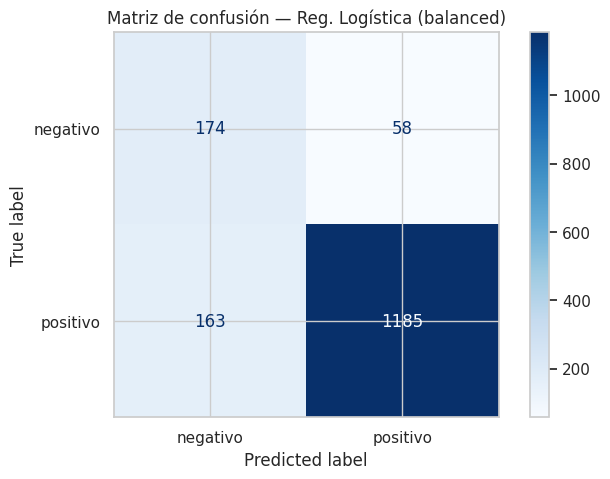

In [97]:
# Matriz de confusión — Reg. Logística (balanced)
cm = confusion_matrix(y_test, y_pred_lr_bal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_lr_bal.classes_)
disp.plot(cmap='Blues')
plt.title("Matriz de confusión — Reg. Logística (balanced)")
plt.show()

In [98]:
# Regresión Logística con Bag of Words
modelo_bow = LogisticRegression(max_iter=1000, random_state=SEED)
modelo_bow.fit(X_train_bow, y_train)
y_pred_bow = modelo_bow.predict(X_test_bow)
acc_bow = accuracy_score(y_test, y_pred_bow)

print(f"Accuracy BOW: {acc_bow:.4f}")
print(classification_report(y_test, y_pred_bow))

Accuracy BOW: 0.8854
              precision    recall  f1-score   support

    negativo       0.65      0.49      0.56       232
    positivo       0.92      0.95      0.93      1348

    accuracy                           0.89      1580
   macro avg       0.78      0.72      0.74      1580
weighted avg       0.88      0.89      0.88      1580



---
## Fase 4: Comparación de resultados

### 4.1 Tabla comparativa de todos los modelos

In [99]:
# ==========================================
# TABLA COMPARATIVA FINAL
# ==========================================

# F1-score macro para todos los modelos
f1_lr    = f1_score(y_test, y_pred_lr,     average='macro')
f1_bow   = f1_score(y_test, y_pred_bow,    average='macro')
f1_lr_b  = f1_score(y_test, y_pred_lr_bal, average='macro')
f1_dl    = f1_score(y_true_labels, y_pred_labels, average='macro')

resultados = pd.DataFrame({
    'Modelo': [
        'Reg. Logística (TF-IDF)',
        'Reg. Logística (TF-IDF, balanced)',
        'Reg. Logística (BOW)',
        'Red Neuronal PyTorch (TF-IDF)'
    ],
    'Vectorización': ['TF-IDF', 'TF-IDF', 'BOW', 'TF-IDF'],
    'Accuracy': [acc_lr, acc_lr_bal, acc_bow, test_acc_dl],
    'F1 Macro': [f1_lr, f1_lr_b, f1_bow, f1_dl]
})

resultados = resultados.sort_values('F1 Macro', ascending=False).reset_index(drop=True)
resultados['Accuracy'] = resultados['Accuracy'].map('{:.4f}'.format)
resultados['F1 Macro'] = resultados['F1 Macro'].map('{:.4f}'.format)

print("=" * 65)
print("COMPARACIÓN DE MODELOS")
print("=" * 65)
print(resultados.to_string(index=False))

COMPARACIÓN DE MODELOS
                           Modelo Vectorización Accuracy F1 Macro
Reg. Logística (TF-IDF, balanced)        TF-IDF   0.8601   0.7632
             Reg. Logística (BOW)           BOW   0.8854   0.7448
    Red Neuronal PyTorch (TF-IDF)        TF-IDF   0.8025   0.6885
          Reg. Logística (TF-IDF)        TF-IDF   0.8867   0.6674


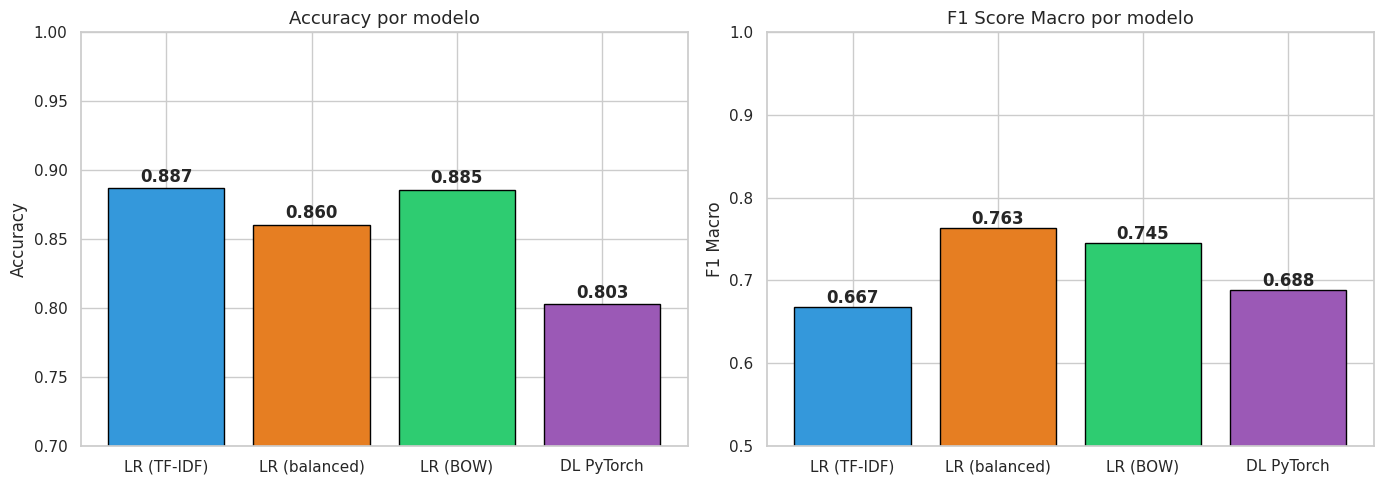

In [100]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']
modelos_short = ['LR (TF-IDF)', 'LR (balanced)', 'LR (BOW)', 'DL PyTorch']
acc_vals = [acc_lr, acc_lr_bal, acc_bow, test_acc_dl]
f1_vals  = [f1_lr, f1_lr_b, f1_bow, f1_dl]

axes[0].bar(modelos_short, acc_vals, color=colores, edgecolor='black')
axes[0].set_title('Accuracy por modelo', fontsize=13)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.7, 1.0)
for i, v in enumerate(acc_vals):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(modelos_short, f1_vals, color=colores, edgecolor='black')
axes[1].set_title('F1 Score Macro por modelo', fontsize=13)
axes[1].set_ylabel('F1 Macro')
axes[1].set_ylim(0.5, 1.0)
for i, v in enumerate(f1_vals):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 4.2 TF-IDF vs Bag of Words

In [101]:
# Comparación directa TF-IDF vs BOW con el mismo modelo
comparacion_vec = pd.DataFrame({
    'Técnica': ['TF-IDF', 'Bag of Words'],
    'Accuracy': [acc_lr, acc_bow],
    'F1 Macro': [f1_lr, f1_bow]
})
print(comparacion_vec.to_string(index=False))

     Técnica  Accuracy  F1 Macro
      TF-IDF  0.886709  0.667392
Bag of Words  0.885443  0.744768


---
## Fase 5: Prueba manual del modelo

### 5.1 Predicciones con Regresión Logística

In [102]:
nuevas_resenas = [
    "La película fue excelente, me encantó la historia y los actores",
    "Muy mala, aburrida y sin sentido, no la recomiendo para nada",
    "No estuvo tan mal, pero esperaba mucho más de este director",
    "Una obra maestra del cine, imprescindible verla",
    "Un desastre total, perdí dos horas de mi vida"
]

nuevas_limpias = [limpiar_texto(r) for r in nuevas_resenas]
nuevas_tfidf   = tfidf.transform(nuevas_limpias)
predicciones_lr = modelo_lr_bal.predict(nuevas_tfidf)

print("PREDICCIONES — Regresión Logística (balanced)")
print("=" * 60)
for resena, pred in zip(nuevas_resenas, predicciones_lr):
    emoji = "✅" if pred == 'positivo' else "❌"
    print(f"{emoji} [{pred.upper():9s}] {resena[:60]}")

PREDICCIONES — Regresión Logística (balanced)
✅ [POSITIVO ] La película fue excelente, me encantó la historia y los acto
❌ [NEGATIVO ] Muy mala, aburrida y sin sentido, no la recomiendo para nada
✅ [POSITIVO ] No estuvo tan mal, pero esperaba mucho más de este director
✅ [POSITIVO ] Una obra maestra del cine, imprescindible verla
✅ [POSITIVO ] Un desastre total, perdí dos horas de mi vida


### 5.2 Predicciones con la Red Neuronal (PyTorch)

In [103]:
# Predicción con el modelo DL
model.eval()
nuevas_tensor = torch.tensor(nuevas_tfidf.toarray(), dtype=torch.float32).to(device)

with torch.no_grad():
    outputs  = model(nuevas_tensor)
    probs    = torch.softmax(outputs, dim=1)
    preds_dl = torch.argmax(outputs, dim=1).cpu().numpy()

predicciones_dl = le.inverse_transform(preds_dl)
probs_np = probs.cpu().numpy()

print("PREDICCIONES — Red Neuronal PyTorch")
print("=" * 60)
clases = le.classes_
for resena, pred, prob in zip(nuevas_resenas, predicciones_dl, probs_np):
    emoji = "✅" if pred == 'positivo' else "❌"
    confianza = max(prob)
    print(f"{emoji} [{pred.upper():9s}] (confianza: {confianza:.2%}) {resena[:50]}")

PREDICCIONES — Red Neuronal PyTorch
✅ [POSITIVO ] (confianza: 99.99%) La película fue excelente, me encantó la historia 
❌ [NEGATIVO ] (confianza: 90.25%) Muy mala, aburrida y sin sentido, no la recomiendo
❌ [NEGATIVO ] (confianza: 99.54%) No estuvo tan mal, pero esperaba mucho más de este
✅ [POSITIVO ] (confianza: 100.00%) Una obra maestra del cine, imprescindible verla
✅ [POSITIVO ] (confianza: 89.57%) Un desastre total, perdí dos horas de mi vida


---
## Conclusiones

En este trabajo se desarrolló un pipeline completo de análisis de sentimiento sobre reseñas de películas en español, abarcando todas las etapas requeridas:

### Hallazgos principales

**1. Preprocesamiento:**
La limpieza con expresiones regulares fue efectiva para normalizar el texto. La comparación entre NLTK y spaCy evidenció que `WordNetLemmatizer` no es adecuado para español, ya que devuelve los tokens sin transformación en la mayoría de los casos. spaCy con `es_core_news_sm` lematiza correctamente formas como "películas" → "película" o "vieron" → "ver".

**2. Vectorización:**
TF-IDF y Bag of Words obtuvieron resultados similares (~88% accuracy con Regresión Logística), lo que indica que para este corpus la frecuencia bruta ya captura los patrones de sentimiento. TF-IDF sigue siendo la opción más recomendable en términos de escalabilidad.

**3. Deep Learning:**
El modelo TextClassifier en PyTorch presentó sobreajuste evidente, mitigado parcialmente por Dropout y Early Stopping. El desempeño final en test fue comparable al modelo clásico. Esto ilustra un patrón frecuente en NLP: para representaciones estáticas como TF-IDF, los modelos lineales suelen ser suficientes y más estables.

**4. Desbalance de clases:**
El ajuste con `class_weight='balanced'` redujo el accuracy global pero mejoró significativamente el recall de la clase negativa (minoritaria), produciendo un modelo más equilibrado y útil en la práctica.

### Posibles mejoras
- Incorporar embeddings preentrenados en español (FastText, BETO) para capturar semántica contextual
- Aplicar técnicas de balanceo de datos (SMOTE, oversampling) sobre la clase negativa
- Explorar arquitecturas más profundas (LSTM, CNN) o transformers (BERT en español)
- Aumentar el dataset con más reseñas negativas para reducir el desbalance estructural